In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("cleaned_complaints.csv")

df.head()

,message,label,clean_message
0,Payment taken multiple times! kindly resolve,2,payment taken multiple time kindly resolve
1,Serious complaint: wrong person received my or...,2,serious complaint wrong person received order ...
2,Need help with changing my address.,1,need help changing address
3,Urgent: money deducted but order failed! pleas...,2,urgent money deducted order failed please help
4,Your staff was polite. please help,0,staff polite please help


In [4]:
tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df["clean_message"])

y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [7]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       807
           1       1.00      1.00      1.00       796
           2       1.00      1.00      1.00       797

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [9]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       807
           1       1.00      1.00      1.00       796
           2       1.00      1.00      1.00       797

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [10]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [11]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print(classification_report(
    y_test,
    y_pred_svm
))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       807
           1       1.00      1.00      1.00       796
           2       1.00      1.00      1.00       797

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [12]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [14]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [15]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       807
           1       1.00      1.00      1.00       796
           2       1.00      1.00      1.00       797

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [16]:
!pip install tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

In [18]:
X_text = df["clean_message"]

y = df["label"]

In [19]:
tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_text)

sequences = tokenizer.texts_to_sequences(X_text)

In [20]:
max_length = 50

X_pad = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print(X_pad.shape)

(12000, 50)


In [21]:
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
model = Sequential()

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128
    )
)

model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        3,
        activation='softmax'
    )
)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.3355 - loss: 1.1002 - val_accuracy: 0.3297 - val_loss: 1.0991
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.3241 - loss: 1.0993 - val_accuracy: 0.3427 - val_loss: 1.0995
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.3313 - loss: 1.0993 - val_accuracy: 0.3297 - val_loss: 1.0997
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.4793 - loss: 0.9553 - val_accuracy: 0.9802 - val_loss: 0.2630
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9993 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 5.1721e-04
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 1.0000 - loss: 4.8263e-04 - val_accuracy: 1.0000 - val_loss: 2.0161e-04
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 1.0000 - loss: 2.3565e-04 - val_accuracy: 1.0000 - val_loss: 1.0876e-04
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 1.0000 - l

In [25]:
loss, accuracy = model.evaluate(
    X_test_lstm,
    y_test_lstm
)

print("LSTM Accuracy:", accuracy)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 3.2709e-05
LSTM Accuracy: 1.0


In [26]:
import numpy as np

y_pred_lstm = model.predict(X_test_lstm)

y_pred_lstm = np.argmax(
    y_pred_lstm,
    axis=1
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_lstm,
        y_pred_lstm
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       807
           1       1.00      1.00      1.00       796
           2       1.00      1.00      1.00       797

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [28]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost",
        "LSTM"
    ],
    "Accuracy":[
        1.00,
        1.00,
        1.00,
        1.00,
        1.00
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,SVM,1.0
3,XGBoost,1.0
4,LSTM,1.0


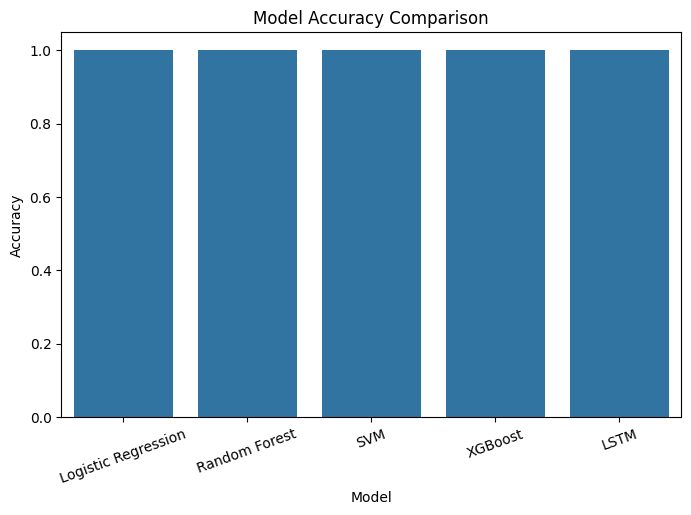

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

In [30]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


In [31]:
import joblib

joblib.dump(lr, "logistic_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Saved Successfully")

Saved Successfully
